# Ensemble Classification & Decision Tree Regression
This notebook implements an ensemble classifier using Voting (soft) for loan approval prediction, and Decision Tree regression for predicting maximum loan amount. It includes model training, evaluation, comparison, and visualization.

---
# PART 1: Ensemble Classification
Build a Voting Classifier combining Logistic Regression and KNN to predict loan approval status.

---

## 1.1 Import Required Libraries
Import all libraries needed for ensemble classification, evaluation, and plotting.

In [21]:
# Import ensemble classifier
from sklearn.ensemble import VotingClassifier

# Import base classifiers
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier

# Import evaluation metrics
from sklearn import metrics
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score
)

# Import train-test split
from sklearn.model_selection import train_test_split

# Import plotting and data libraries
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

## 1.2 Run Notebook 1 (Preprocessing)
Execute the preprocessing notebook to load all prepared variables into this notebook.

=== Libraries Imported Successfully ===
pandas, numpy, matplotlib, seaborn, sklearn.preprocessing
=== First 5 Rows of the Dataset ===
      id   age  income home_ownership  emplyment_length      loan_intent  \
0  35437  21.0   12000            OWN                 0        EDUCATION   
1  53756  21.0   13200            OWN                 2        EDUCATION   
2  42205  23.0    9600           RENT                 5          MEDICAL   
3  19180  40.0  182004           RENT                 3        EDUCATION   
4  28072  40.0   90000       MORTGAGE                 3  HOMEIMPROVEMENT   

   loan_amount  loan_interest_rate  loan_income_ratio payment_default_on_file  \
0        15000                6.99               0.12                       N   
1        25000               16.77               0.19                       Y   
2        30000               12.42               0.31                       N   
3        35000                8.00               0.19                       N   
4   

/var/folders/nm/q3h2bx4x5cddhflsszkgt2zr0000gn/T/ipykernel_15573/503983387.py:9: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = df.select_dtypes(include=['object']).columns.tolist()
/var/folders/nm/q3h2bx4x5cddhflsszkgt2zr0000gn/T/ipykernel_15573/997376871.py:18: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warni

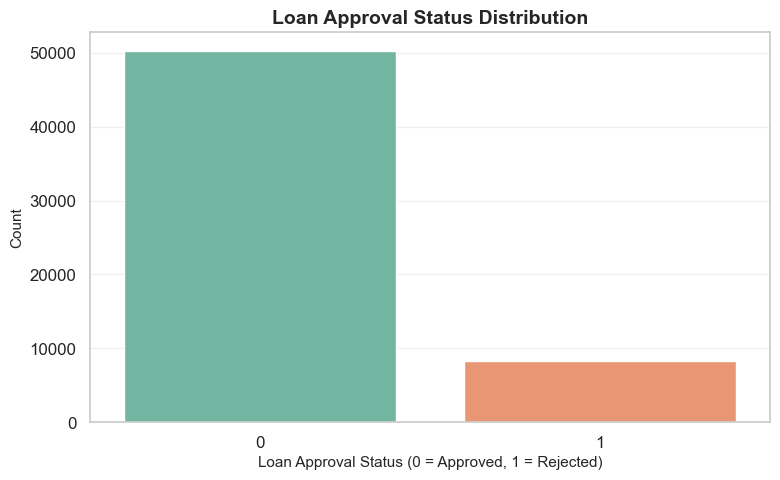

Total Applications: 58645
Approved: 50295 (85.76%)
Rejected: 8350 (14.24%)
=== Regression Dataset Created (Approved Loans Only) ===
X_regression shape: (50295, 10)
y_regression shape: (50295,)

=== Regression Target Statistics ===
count    5.029500e+04
mean     8.133543e+04
std      5.919723e+04
min     -2.426900e+06
25%      4.909150e+04
50%      6.942700e+04
75%      9.898900e+04
max      2.638778e+06
Name: max_allowed_loan, dtype: float64
=== Feature Scaling Complete (Classification) ===
X_classification_scaled shape: (58645, 11)
Mean (should be ~0): -0.000000
Std  (should be ~1): 1.000000

=== Feature Scaling Complete (Regression) ===
X_regression_scaled shape: (50295, 10)
Mean (should be ~0): -0.000000
Std  (should be ~1): 1.000000
=== Classification Scaled Data ===
Type: DataFrame
Columns: ['age', 'income', 'home_ownership', 'emplyment_length', 'loan_intent', 'loan_amount', 'loan_interest_rate', 'loan_income_ratio', 'payment_default_on_file', 'credit_history_length', 'max_allowed

In [22]:
# Run Notebook 1 to execute all preprocessing steps
# This loads X_classification_scaled, y_classification, X_regression_scaled, y_regression
from IPython import get_ipython
get_ipython().run_line_magic('run', 'loan_data_preprocessing.ipynb')


## 1.3 Load Classification Data
Assign the preprocessed classification features and target variable.

In [23]:
# Safety check: ensure classification variables exist
if 'X_classification_scaled' not in dir():
    raise ValueError("Preprocessed data not loaded. Run Notebook 1 first.")

# Assign preprocessed classification variables
X_cls = X_classification_scaled
y_cls = y_classification

# Confirm data loaded successfully
print('=' * 50)
print('CLASSIFICATION DATA LOADED')
print('=' * 50)
print(f'X_cls shape: {X_cls.shape}')
print(f'y_cls shape: {y_cls.shape}')

CLASSIFICATION DATA LOADED
X_cls shape: (58645, 11)
y_cls shape: (58645,)


## 1.4 Train-Test Split (Classification)
Split the classification data into 80% training and 20% testing with stratification.

In [24]:
# Split classification data into training and testing sets
# stratify=y_cls preserves class proportions in both sets
X_train_cls, X_test_cls, y_train_cls, y_test_cls = train_test_split(
    X_cls, y_cls,
    test_size=0.2,
    random_state=42,
    stratify=y_cls
)

# Print split summary
print('=' * 50)
print('CLASSIFICATION TRAIN-TEST SPLIT')
print('=' * 50)
print(f'Training set: {X_train_cls.shape[0]} samples')
print(f'Testing set:  {X_test_cls.shape[0]} samples')
print(f'\nTraining class distribution:')
print(y_train_cls.value_counts().sort_index())
print(f'\nTesting class distribution:')
print(y_test_cls.value_counts().sort_index())

CLASSIFICATION TRAIN-TEST SPLIT
Training set: 46916 samples
Testing set:  11729 samples

Training class distribution:
loan_approval_status
0    40236
1     6680
Name: count, dtype: int64

Testing class distribution:
loan_approval_status
0    10059
1     1670
Name: count, dtype: int64


## 1.5 Create Base Models
Define the individual classifiers that will be combined in the ensemble.

In [25]:
# Create Logistic Regression classifier
lr_model = LogisticRegression(max_iter=1000, random_state=42)

# Create K-Nearest Neighbors classifier
knn_model = KNeighborsClassifier(n_neighbors=5)

# Confirm base models created
print('=== Base Models Created ===')
print(f'  1. Logistic Regression: {lr_model}')
print(f'  2. KNN:                 {knn_model}')

=== Base Models Created ===
  1. Logistic Regression: LogisticRegression(max_iter=1000, random_state=42)
  2. KNN:                 KNeighborsClassifier()


## 1.6 Build Ensemble Classifier
Combine the base models into a VotingClassifier using soft voting (probability-based).

In [26]:
# Build VotingClassifier with soft voting
# Soft voting uses predicted probabilities to make the final decision
# This generally performs better than hard voting (majority rule)
ensemble_model = VotingClassifier(
    estimators=[
        ('lr', lr_model),
        ('knn', knn_model)
    ],
    voting='soft'
)

# Confirm ensemble created
print('=== Ensemble Classifier Created ===')
print(f'  Type: VotingClassifier (soft voting)')
print(f'  Base models: Logistic Regression + KNN')
print(f'  {ensemble_model}')

=== Ensemble Classifier Created ===
  Type: VotingClassifier (soft voting)
  Base models: Logistic Regression + KNN
  VotingClassifier(estimators=[('lr',
                              LogisticRegression(max_iter=1000,
                                                 random_state=42)),
                             ('knn', KNeighborsClassifier())],
                 voting='soft')


## 1.7 Train Ensemble Model
Fit the ensemble classifier on the training data.

In [27]:
# Train the ensemble model on the training data
ensemble_model.fit(X_train_cls, y_train_cls)

# Confirm training complete
print('=== Ensemble Model Trained Successfully ===')

=== Ensemble Model Trained Successfully ===


## 1.8 Evaluate Ensemble Model
Make predictions and calculate all key evaluation metrics for the ensemble classifier.

In [28]:
# Predict on test data using the ensemble model
y_pred_ens = ensemble_model.predict(X_test_cls)

# Get probability scores for the positive class (Rejected = 1)
y_score_ens = ensemble_model.predict_proba(X_test_cls)[:, 1]

# Calculate evaluation metrics
accuracy_ens = metrics.accuracy_score(y_test_cls, y_pred_ens)
recall_ens = metrics.recall_score(y_test_cls, y_pred_ens, pos_label=1)
precision_ens = metrics.precision_score(y_test_cls, y_pred_ens, pos_label=1)
f1_ens = metrics.f1_score(y_test_cls, y_pred_ens, pos_label=1)
auc_ens = roc_auc_score(y_test_cls, y_score_ens)

# Print full evaluation
print('=' * 60)
print('ENSEMBLE CLASSIFIER EVALUATION')
print('=' * 60)

# Print confusion matrix
print('\n--- Confusion Matrix ---')
cm_ens = confusion_matrix(y_test_cls, y_pred_ens)
print(cm_ens)

# Print classification report
print('\n--- Classification Report ---')
print(classification_report(y_test_cls, y_pred_ens, target_names=['Approved (0)', 'Rejected (1)']))

# Print key metrics
print('--- Key Metrics ---')
print(f'  Accuracy:  {accuracy_ens:.4f}')
print(f'  Recall:    {recall_ens:.4f}   (pos_label=1, Rejected)')
print(f'  Precision: {precision_ens:.4f}')
print(f'  F1-Score:  {f1_ens:.4f}')
print(f'  AUC-ROC:   {auc_ens:.4f}')

ENSEMBLE CLASSIFIER EVALUATION

--- Confusion Matrix ---
[[10023    36]
 [   35  1635]]

--- Classification Report ---
              precision    recall  f1-score   support

Approved (0)       1.00      1.00      1.00     10059
Rejected (1)       0.98      0.98      0.98      1670

    accuracy                           0.99     11729
   macro avg       0.99      0.99      0.99     11729
weighted avg       0.99      0.99      0.99     11729

--- Key Metrics ---
  Accuracy:  0.9939
  Recall:    0.9790   (pos_label=1, Rejected)
  Precision: 0.9785
  F1-Score:  0.9787
  AUC-ROC:   0.9996


## 1.9 ROC Curve (Ensemble Classifier)
Plot the ROC curve for the ensemble classifier with its AUC score.

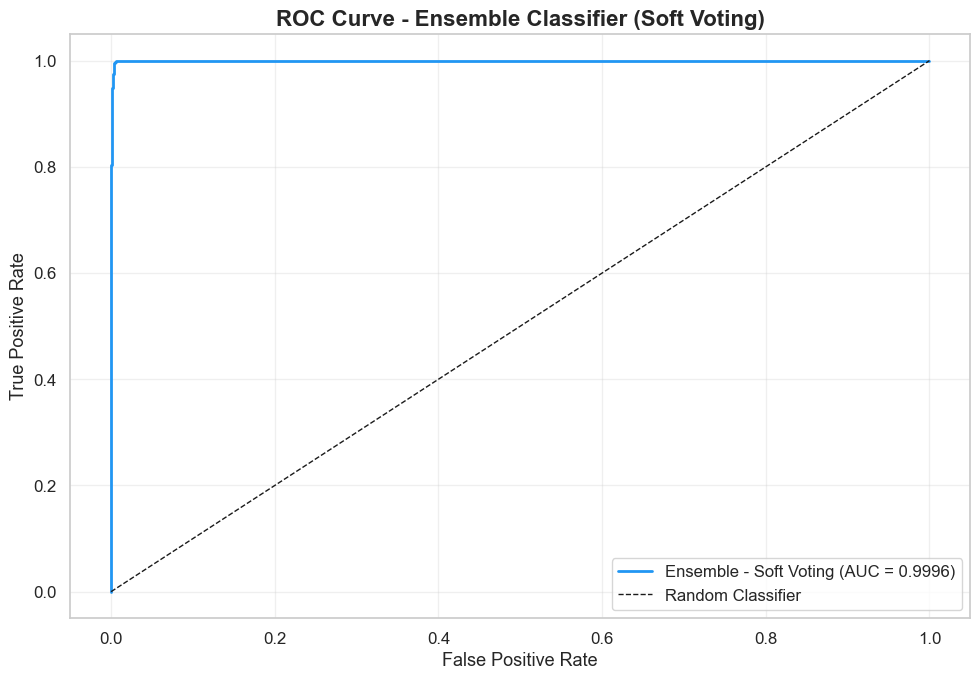

Ensemble AUC-ROC Score: 0.9996


In [29]:
# Calculate false positive rate and true positive rate for ROC curve
fpr_ens, tpr_ens, _ = roc_curve(y_test_cls, y_score_ens)

# Create the ROC curve plot
plt.figure(figsize=(10, 7))

# Plot the ensemble ROC curve
plt.plot(fpr_ens, tpr_ens, linewidth=2, color='#2196F3',
         label=f'Ensemble - Soft Voting (AUC = {auc_ens:.4f})')

# Plot the diagonal baseline (random classifier)
plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Classifier')

# Format the plot
plt.title('ROC Curve - Ensemble Classifier (Soft Voting)', fontsize=16, fontweight='bold')
plt.xlabel('False Positive Rate', fontsize=13)
plt.ylabel('True Positive Rate', fontsize=13)
plt.legend(fontsize=12, loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Print AUC score
print(f'Ensemble AUC-ROC Score: {auc_ens:.4f}')

## 1.10 Ensemble Classification Summary
Final summary of the ensemble classification results.

In [30]:
# Print final ensemble classification summary
print('=' * 60)
print('ENSEMBLE CLASSIFICATION - FINAL SUMMARY')
print('=' * 60)
print(f'\n  Ensemble Type:  VotingClassifier (soft voting)')
print(f'  Base Models:    Logistic Regression + KNN')
print(f'  Train Samples:  {X_train_cls.shape[0]}')
print(f'  Test Samples:   {X_test_cls.shape[0]}')
print(f'\n  Accuracy:       {accuracy_ens:.4f}')
print(f'  Recall:         {recall_ens:.4f}   (Rejected class)')
print(f'  Precision:      {precision_ens:.4f}')
print(f'  F1-Score:       {f1_ens:.4f}')
print(f'  AUC-ROC:        {auc_ens:.4f}')
print('=' * 60)

ENSEMBLE CLASSIFICATION - FINAL SUMMARY

  Ensemble Type:  VotingClassifier (soft voting)
  Base Models:    Logistic Regression + KNN
  Train Samples:  46916
  Test Samples:   11729

  Accuracy:       0.9939
  Recall:         0.9790   (Rejected class)
  Precision:      0.9785
  F1-Score:       0.9787
  AUC-ROC:        0.9996


---
# PART 2: Decision Tree Regression
Build and compare two Decision Tree regressors to predict maximum loan amount using only approved loans.

---

## 2.1 Import Regression Libraries
Import Decision Tree regressor and regression evaluation metrics.

In [31]:
# Import Decision Tree Regressor
from sklearn.tree import DecisionTreeRegressor, plot_tree

# Import regression evaluation metrics
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

## 2.2 Load Regression Data
Assign the preprocessed regression features and target variable (approved loans only).

In [32]:
# Safety check: ensure regression variables exist
if 'X_regression_scaled' not in dir():
    raise ValueError("Regression data not loaded. Run Notebook 1 first.")

# Assign preprocessed regression variables
X_reg = X_regression_scaled
y_reg = y_regression

# Confirm data loaded successfully
print('=' * 50)
print('REGRESSION DATA LOADED')
print('=' * 50)
print(f'X_reg shape: {X_reg.shape}')
print(f'y_reg shape: {y_reg.shape}')
print(f'\nTarget (Maximum Loan Amount) statistics:')
print(y_reg.describe())

REGRESSION DATA LOADED
X_reg shape: (50295, 10)
y_reg shape: (50295,)

Target (Maximum Loan Amount) statistics:
count    5.029500e+04
mean     8.133543e+04
std      5.919723e+04
min     -2.426900e+06
25%      4.909150e+04
50%      6.942700e+04
75%      9.898900e+04
max      2.638778e+06
Name: max_allowed_loan, dtype: float64


## 2.3 Train-Test Split (Regression)
Split the regression data into 80% training and 20% testing.

In [33]:
# Split regression data into training and testing sets
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg, y_reg,
    test_size=0.2,
    random_state=42
)

# Print split summary
print('=' * 50)
print('REGRESSION TRAIN-TEST SPLIT')
print('=' * 50)
print(f'Training set: {X_train_reg.shape[0]} samples')
print(f'Testing set:  {X_test_reg.shape[0]} samples')

REGRESSION TRAIN-TEST SPLIT
Training set: 40236 samples
Testing set:  10059 samples


## 2.4 Train Decision Tree Models
Train two Decision Tree regressors: one with default settings and one with max_depth=4 to control overfitting.

In [34]:
# Create Decision Tree 1: default parameters (no depth limit)
dt1 = DecisionTreeRegressor(random_state=42)

# Create Decision Tree 2: limited depth (max_depth=4) to prevent overfitting
dt2 = DecisionTreeRegressor(max_depth=4, random_state=42)

# Train both models on the training data
dt1.fit(X_train_reg, y_train_reg)
dt2.fit(X_train_reg, y_train_reg)

# Confirm training complete
print('=== Decision Tree Models Trained ===')
print(f'  DT1 (Default):     max_depth = {dt1.get_depth()}')
print(f'  DT2 (max_depth=4): max_depth = {dt2.get_depth()}')

=== Decision Tree Models Trained ===
  DT1 (Default):     max_depth = 24
  DT2 (max_depth=4): max_depth = 4


## 2.5 Predict with Both Models
Generate predictions on the test set using both Decision Tree models.

In [35]:
# Predict on test data using DT1 (default)
y_pred_dt1 = dt1.predict(X_test_reg)

# Predict on test data using DT2 (max_depth=4)
y_pred_dt2 = dt2.predict(X_test_reg)

# Confirm predictions generated
print('=== Predictions Generated ===')
print(f'  DT1 predictions: {y_pred_dt1.shape[0]} values')
print(f'  DT2 predictions: {y_pred_dt2.shape[0]} values')

=== Predictions Generated ===
  DT1 predictions: 10059 values
  DT2 predictions: 10059 values


## 2.6 Evaluate Decision Tree Models
Calculate MSE, MAE, and R² for both models and display results clearly.

In [36]:
# --- Evaluate DT1 (Default) ---
mse_dt1 = mean_squared_error(y_test_reg, y_pred_dt1)
mae_dt1 = mean_absolute_error(y_test_reg, y_pred_dt1)
r2_dt1 = r2_score(y_test_reg, y_pred_dt1)

print('=' * 60)
print('MODEL 1: Decision Tree (Default - No Depth Limit)')
print('=' * 60)
print(f'  Tree Depth: {dt1.get_depth()}')
print(f'  MSE:  {mse_dt1:.4f}')
print(f'  MAE:  {mae_dt1:.4f}')
print(f'  R²:   {r2_dt1:.4f}')

# --- Evaluate DT2 (max_depth=4) ---
mse_dt2 = mean_squared_error(y_test_reg, y_pred_dt2)
mae_dt2 = mean_absolute_error(y_test_reg, y_pred_dt2)
r2_dt2 = r2_score(y_test_reg, y_pred_dt2)

print(f'\n{"=" * 60}')
print('MODEL 2: Decision Tree (max_depth=4)')
print('=' * 60)
print(f'  Tree Depth: {dt2.get_depth()}')
print(f'  MSE:  {mse_dt2:.4f}')
print(f'  MAE:  {mae_dt2:.4f}')
print(f'  R²:   {r2_dt2:.4f}')

MODEL 1: Decision Tree (Default - No Depth Limit)
  Tree Depth: 24
  MSE:  69738517.9095
  MAE:  1244.9190
  R²:   0.9765

MODEL 2: Decision Tree (max_depth=4)
  Tree Depth: 4
  MSE:  404642149.1825
  MAE:  11935.2578
  R²:   0.8639


## 2.7 Compare Regression Models
Side-by-side comparison of both Decision Tree models in a clear tabular format.

In [37]:
# Create comparison table
print('=' * 60)
print('REGRESSION MODEL COMPARISON')
print('=' * 60)

# Build a DataFrame for clean tabular display
comparison_reg = pd.DataFrame({
    'Metric': ['Tree Depth', 'MSE', 'MAE', 'R²'],
    'DT1 (Default)': [
        dt1.get_depth(),
        round(mse_dt1, 4),
        round(mae_dt1, 4),
        round(r2_dt1, 4)
    ],
    'DT2 (max_depth=4)': [
        dt2.get_depth(),
        round(mse_dt2, 4),
        round(mae_dt2, 4),
        round(r2_dt2, 4)
    ]
})

# Set Metric as index for cleaner display
comparison_reg = comparison_reg.set_index('Metric')
print(comparison_reg.to_string())

# Determine best model based on R² score
if r2_dt1 > r2_dt2:
    print(f'\nBest Model: DT1 (Default) with R² = {r2_dt1:.4f}')
else:
    print(f'\nBest Model: DT2 (max_depth=4) with R² = {r2_dt2:.4f}')

# Note about overfitting
print('\nNote: DT1 (no depth limit) may overfit the training data.')
print('DT2 (max_depth=4) is a simpler model that may generalise better.')

REGRESSION MODEL COMPARISON
            DT1 (Default)  DT2 (max_depth=4)
Metric                                      
Tree Depth   2.400000e+01       4.000000e+00
MSE          6.973852e+07       4.046421e+08
MAE          1.244919e+03       1.193526e+04
R²           9.765000e-01       8.639000e-01

Best Model: DT1 (Default) with R² = 0.9765

Note: DT1 (no depth limit) may overfit the training data.
DT2 (max_depth=4) is a simpler model that may generalise better.


## 2.8 Visualize Decision Trees
Plot both decision trees to understand their structure and decision-making process.

=== Decision Tree 1 (Default) ===
Full tree depth: 24 (showing max_depth=3 for readability)


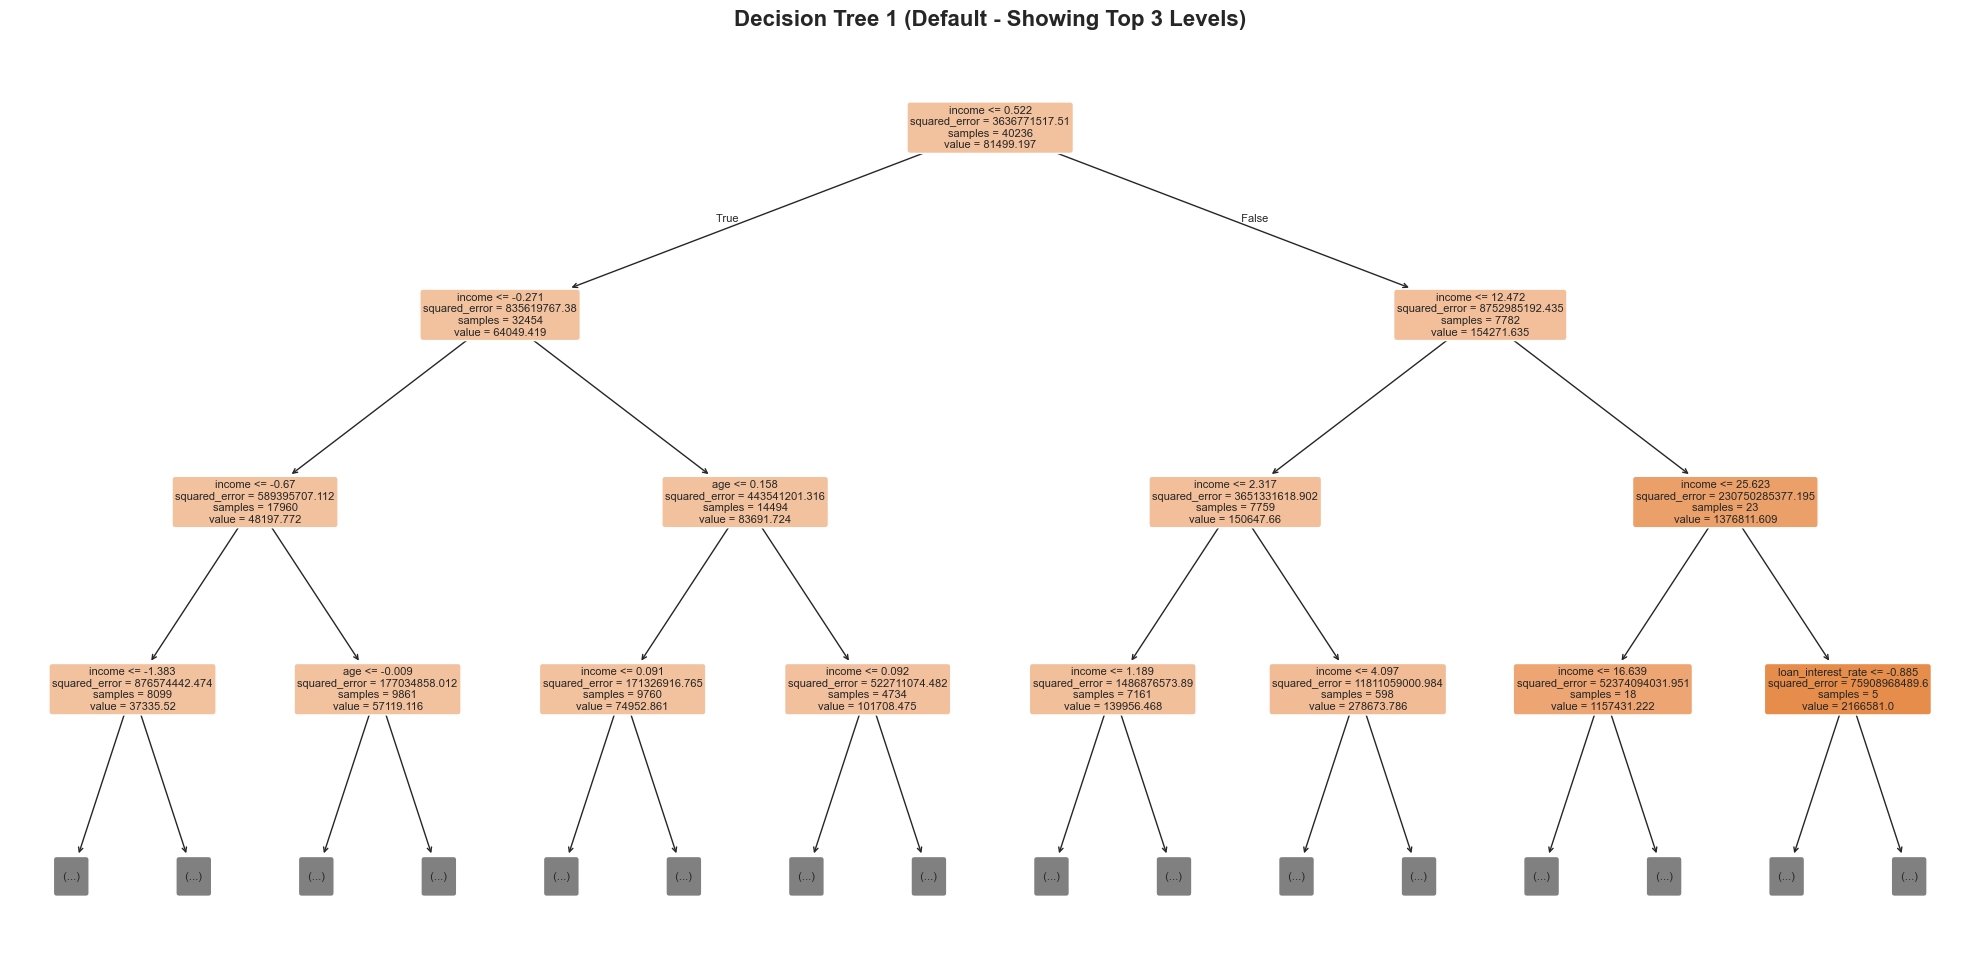

In [38]:
# Get feature names for the tree visualization
if hasattr(X_reg, 'columns'):
    feature_names = X_reg.columns.tolist()
else:
    feature_names = [f'Feature {i}' for i in range(X_reg.shape[1])]

# --- Visualize DT1 (Default) ---
# Note: Default tree may be very large, so we limit display depth
print('=== Decision Tree 1 (Default) ===')
print(f'Full tree depth: {dt1.get_depth()} (showing max_depth=3 for readability)')

plt.figure(figsize=(20, 10))
plot_tree(
    dt1,
    max_depth=3,
    feature_names=feature_names,
    filled=True,
    rounded=True,
    fontsize=8
)
plt.title('Decision Tree 1 (Default - Showing Top 3 Levels)', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

=== Decision Tree 2 (max_depth=4) ===


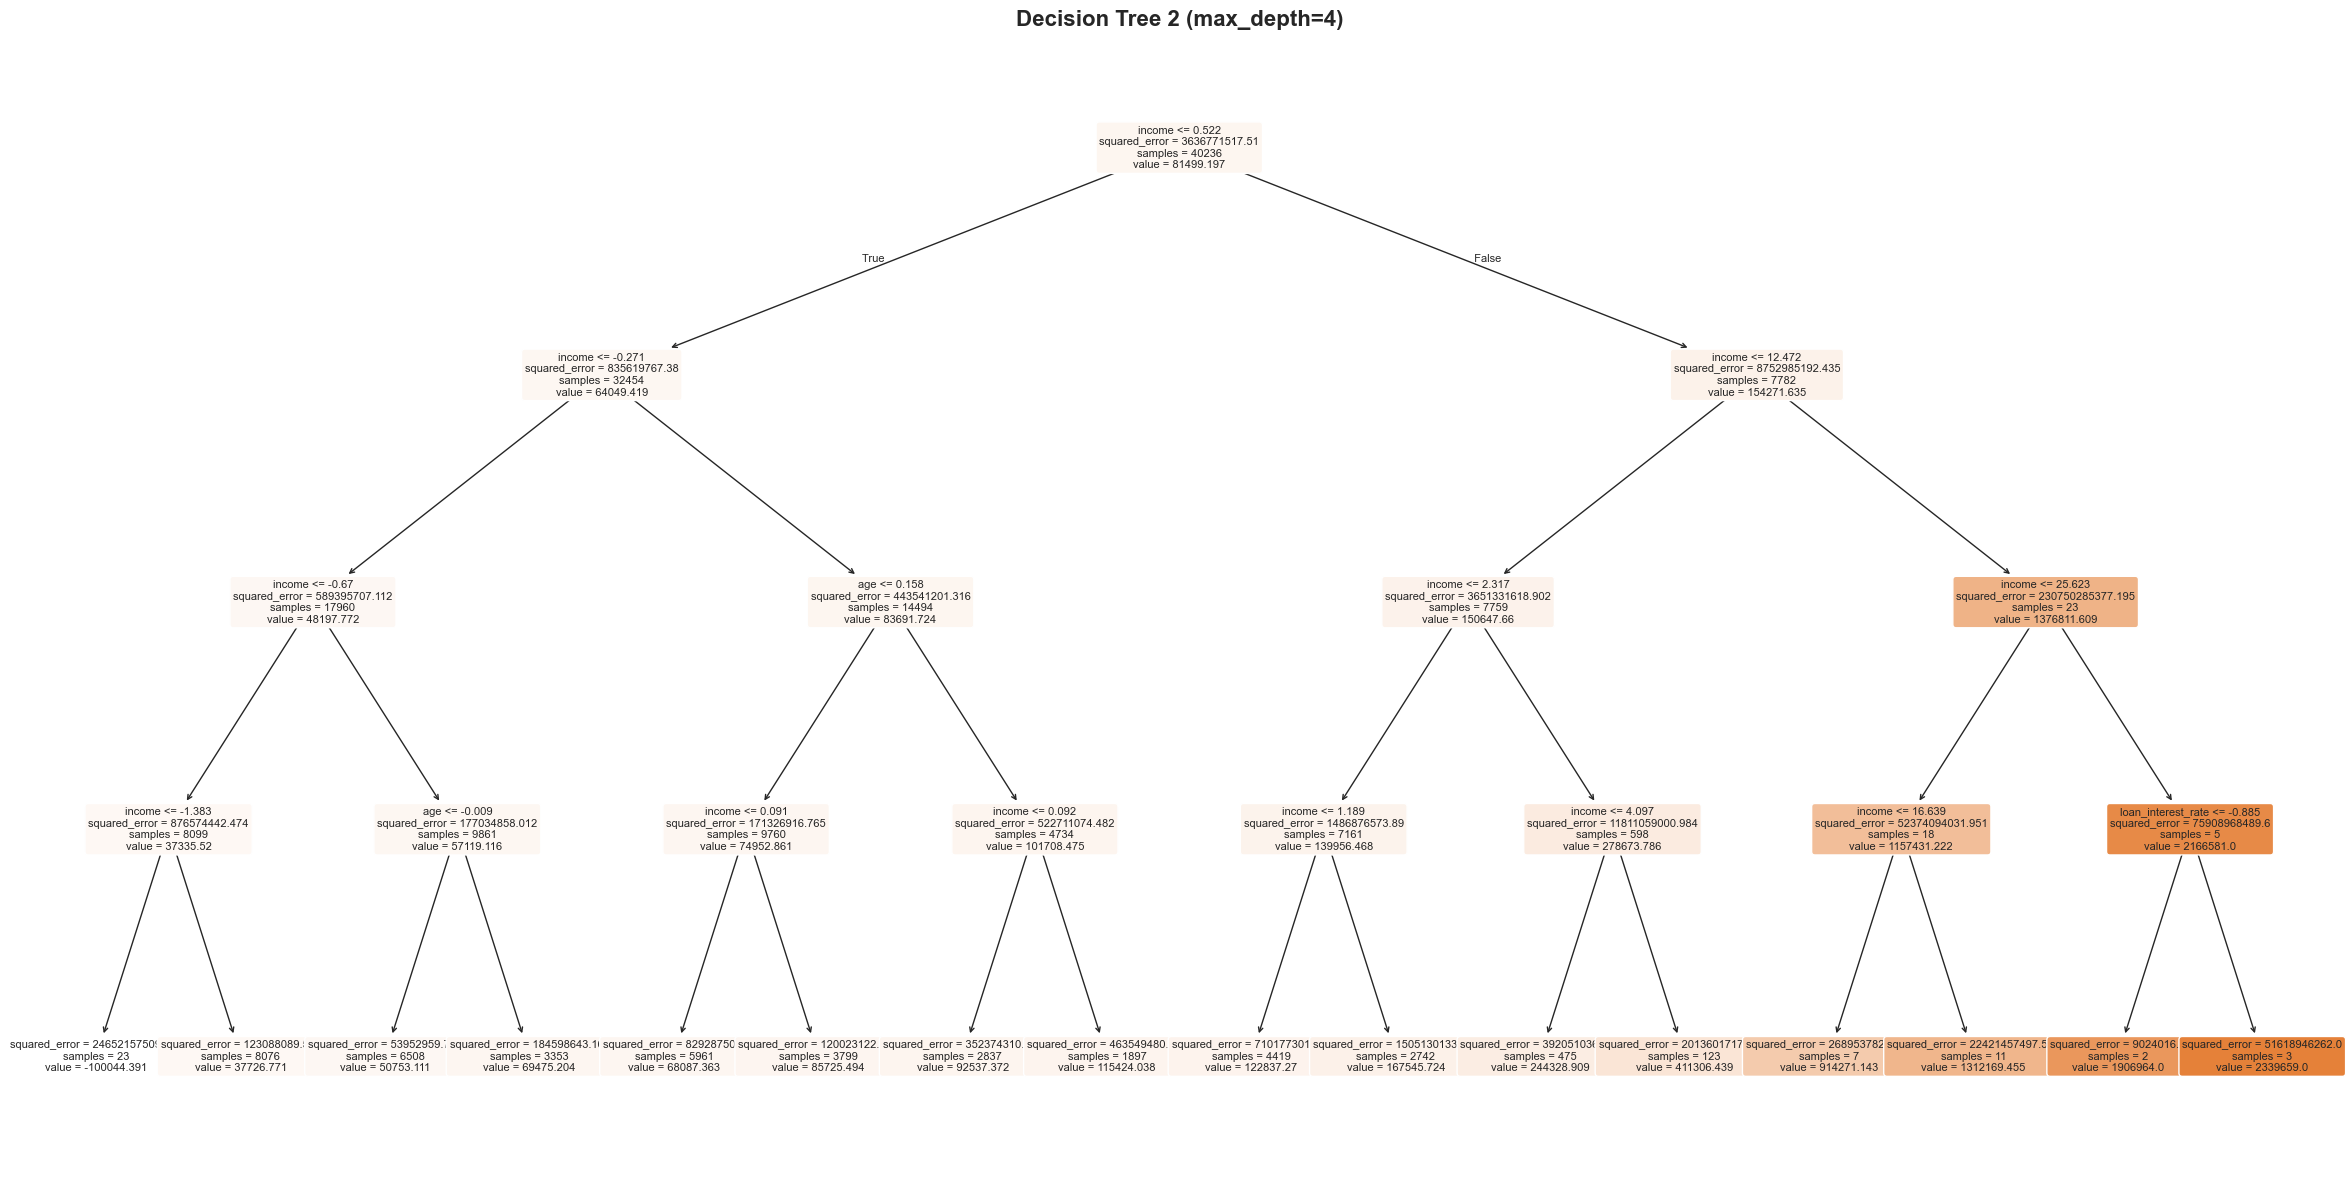

In [39]:
# --- Visualize DT2 (max_depth=4) ---
print('=== Decision Tree 2 (max_depth=4) ===')

plt.figure(figsize=(24, 12))
plot_tree(
    dt2,
    feature_names=feature_names,
    filled=True,
    rounded=True,
    fontsize=8
)
plt.title('Decision Tree 2 (max_depth=4)', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

## 2.9 Regression Final Summary
Clean summary of the regression workflow for coursework reporting.

In [40]:
# Print final regression summary
print('=' * 60)
print('REGRESSION WORKFLOW - FINAL SUMMARY')
print('=' * 60)

print(f'\n--- Dataset ---')
print(f'  Features (X): {X_reg.shape}')
print(f'  Target (y):   {y_reg.shape}')
print(f'  Train size:   {X_train_reg.shape[0]} samples')
print(f'  Test size:    {X_test_reg.shape[0]} samples')

print(f'\n--- Model 1: DT (Default) ---')
print(f'  Tree Depth: {dt1.get_depth()}')
print(f'  MSE:  {mse_dt1:.4f}')
print(f'  MAE:  {mae_dt1:.4f}')
print(f'  R²:   {r2_dt1:.4f}')

print(f'\n--- Model 2: DT (max_depth=4) ---')
print(f'  Tree Depth: {dt2.get_depth()}')
print(f'  MSE:  {mse_dt2:.4f}')
print(f'  MAE:  {mae_dt2:.4f}')
print(f'  R²:   {r2_dt2:.4f}')

print(f'\n' + '=' * 60)
print('ENSEMBLE CLASSIFICATION & REGRESSION COMPLETE')
print('=' * 60)

REGRESSION WORKFLOW - FINAL SUMMARY

--- Dataset ---
  Features (X): (50295, 10)
  Target (y):   (50295,)
  Train size:   40236 samples
  Test size:    10059 samples

--- Model 1: DT (Default) ---
  Tree Depth: 24
  MSE:  69738517.9095
  MAE:  1244.9190
  R²:   0.9765

--- Model 2: DT (max_depth=4) ---
  Tree Depth: 4
  MSE:  404642149.1825
  MAE:  11935.2578
  R²:   0.8639

ENSEMBLE CLASSIFICATION & REGRESSION COMPLETE
